## Titanic Survival Prediction

1. Project Overview

The sinking of the RMS Titanic in 1912 is one of the most famous maritime disasters in history. During the tragic event, many passengers lost their lives while others survived due to various factors such as gender, age, passenger class, and access to lifeboats.

This project aims to analyze passenger data from the Titanic and build a machine learning classification model that predicts whether a passenger survived the disaster.

The project demonstrates a complete end-to-end data science workflow, including data exploration, data cleaning, feature engineering, model training, and evaluation.

2. Problem Statement

Given a dataset containing information about Titanic passengers, the goal is to predict whether a passenger survived or not.

This is a binary classification problem where:

1 → Survived

0 → Did Not Survive

3. Project Objective

The objectives of this project are:

Perform exploratory data analysis (EDA) to understand survival patterns

Clean and preprocess the dataset

Engineer meaningful features

Train multiple machine learning classification models

Evaluate and compare model performance

Select the best-performing model

4. Dataset Description

The dataset contains information about passengers on board the Titanic.

Key features include:

Feature	Description
PassengerId	Unique ID for each passenger
Survived	Survival (0 = No, 1 = Yes)
Pclass	Passenger class (1 = First, 2 = Second, 3 = Third)
Name	Passenger name
Sex	Gender of passenger
Age	Passenger age
SibSp	Number of siblings/spouses aboard
Parch	Number of parents/children aboard
Ticket	Ticket number
Fare	Ticket fare
Cabin	Cabin number
Embarked	Port of embarkation
5. Tools and Technologies Used

This project will be implemented using the following Python libraries:

pandas → data manipulation

numpy → numerical operations

matplotlib and seaborn → data visualization

scikit-learn → machine learning modeling and evaluation

6. Machine Learning Workflow

The project will follow a professional machine learning pipeline:

Data loading

Data exploration

Exploratory data analysis

Data cleaning

Feature engineering

Model training

Model evaluation

Model improvement

Final model selection

## Import Libraries

In [2]:

# Import Required Libraries

# Data manipulation
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning model
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression 
from sklearn.tree import DecisionTreeClassifier     
from sklearn.ensemble import RandomForestClassifier

# Model Evaluation
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

## Load Dataset

In [3]:
# Load Titanic dataset
df = pd.read_csv("Titanic-Dataset.csv")

# Display first 5 rows
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## Initial Data Exploration

In [4]:
df.shape

(891, 12)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


### Statistical Summary

In [6]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


### Missing Values

In [7]:
missing_values = df.isnull().sum().sort_values(ascending=False)
missing_values

Cabin          687
Age            177
Embarked         2
PassengerId      0
Name             0
Pclass           0
Survived         0
Sex              0
Parch            0
SibSp            0
Fare             0
Ticket           0
dtype: int64

## Exploratory Data Analysis (EDA)

### Survival Distribution
Visualize how many passengers survived vs. did not survive.

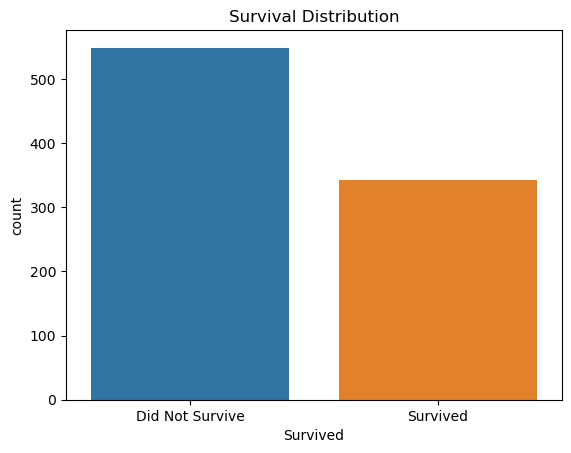

In [8]:
# Count of survival
sns.countplot(x='Survived', data=df, palette=['#1f77b4', '#ff7f0e']) # Blue,Orange Color
plt.title('Survival Distribution')
plt.xticks([0,1], ['Did Not Survive', 'Survived'])
plt.show()

### Survival by Gender
 Check how gender influenced survival.

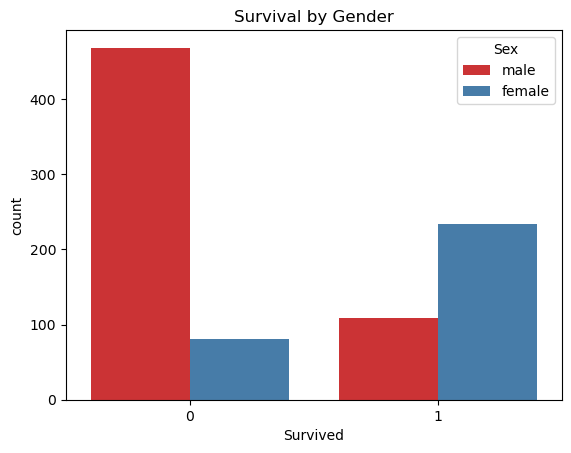

In [9]:
sns.countplot(x='Survived', hue='Sex', data=df, palette='Set1')
plt.title('Survival by Gender')
plt.show()

Females had higher survival rate

Gender is an important feature for the model

### Survival by Passenger Class
Check how passenger class affected survival.

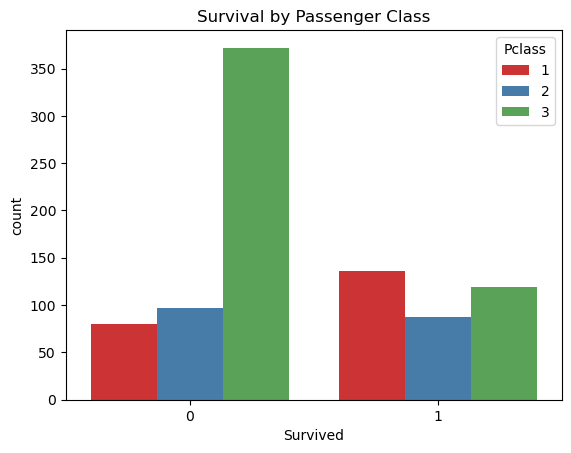

In [10]:
sns.countplot(x='Survived', hue='Pclass', data=df, palette='Set1')
plt.title('Survival by Passenger Class')
plt.show()

Passengers in 1st class survived more often than 2nd and 3rd class

Class is a strong predictor

### Age Distribution
Analyze age distribution of passengers.

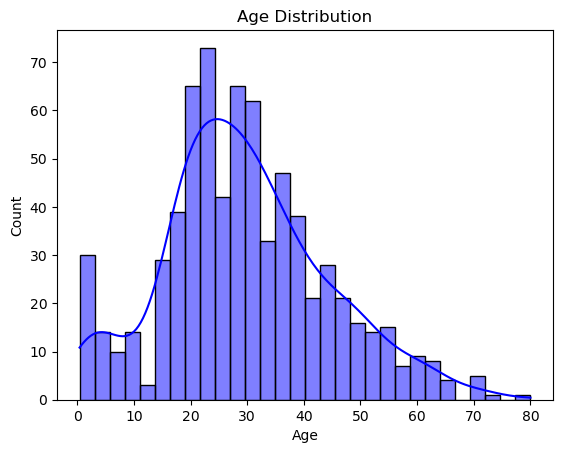

In [11]:
sns.histplot(df['Age'], bins=30, kde=True, color='blue')
plt.title('Age Distribution')
plt.xlabel('Age')
plt.show()

Most passengers were between 20–40 years old

Age may influence survival (children sometimes survived more)

### Family Size vs Survival

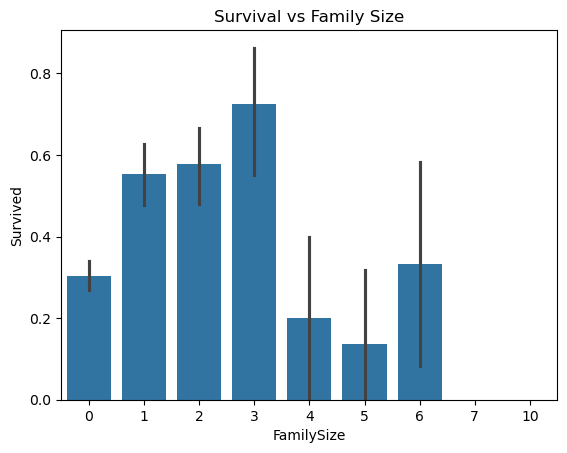

In [12]:
# Create FamilySize
df['FamilySize'] = df['SibSp'] + df['Parch']

sns.barplot(x='FamilySize', y='Survived', data=df)
plt.title('Survival vs Family Size')
plt.show()

Passengers with very large families had lower survival

Medium family size slightly increased chances

## Data Cleaning

### Drop Columns Not Needed for Modeling
PassengerId, Name, and Ticket are not useful for logistic regression.

In [13]:
df.drop(['PassengerId','Name','Ticket'], axis=1, inplace=True)
df

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,FamilySize
0,0,3,male,22.0,1,0,7.2500,NaN,S,1
1,1,1,female,38.0,1,0,71.2833,C85,C,1
2,1,3,female,26.0,0,0,7.9250,NaN,S,0
3,1,1,female,35.0,1,0,53.1000,C123,S,1
4,0,3,male,35.0,0,0,8.0500,NaN,S,0
...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,NaN,S,0
887,1,1,female,19.0,0,0,30.0000,B42,S,0
888,0,3,female,NaN,1,2,23.4500,NaN,S,3
889,1,1,male,26.0,0,0,30.0000,C148,C,0


### Drop Cabin Column
Cabin has too many missing values, so we drop it.

In [14]:
df.drop('Cabin',axis=1,inplace=True)
df

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,FamilySize
0,0,3,male,22.0,1,0,7.2500,S,1
1,1,1,female,38.0,1,0,71.2833,C,1
2,1,3,female,26.0,0,0,7.9250,S,0
3,1,1,female,35.0,1,0,53.1000,S,1
4,0,3,male,35.0,0,0,8.0500,S,0
...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,0
887,1,1,female,19.0,0,0,30.0000,S,0
888,0,3,female,NaN,1,2,23.4500,S,3
889,1,1,male,26.0,0,0,30.0000,C,0


### Fill Missing Age
We fill missing Age values with **median age** (robust to outliers).

In [15]:
# Fill missing Age values with median
df['Age'].fillna(df['Age'].median(), inplace=True)

In [16]:
df.isnull().sum()

Survived      0
Pclass        0
Sex           0
Age           0
SibSp         0
Parch         0
Fare          0
Embarked      2
FamilySize    0
dtype: int64

In [17]:
df.sample(5)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,FamilySize
768,0,3,male,28.0,1,0,24.1500,Q,1
384,0,3,male,28.0,0,0,7.8958,S,0
75,0,3,male,25.0,0,0,7.6500,S,0
178,0,2,male,30.0,0,0,13.0000,S,0
88,1,1,female,23.0,3,2,263.0000,S,5


## Feature Engineering

### Encoding Categorical Variables
Convert categorical columns (Sex, Embarked) into numerical values.

In [18]:
# Convert categorical variables into numerical variables
df = pd.get_dummies(df, columns=['Sex','Embarked'], drop_first=True)

# Preview dataset
df.head()

,Survived,Pclass,Age,SibSp,Parch,Fare,FamilySize,Sex_male,Embarked_Q,Embarked_S
0,0,3,22.0,1,0,7.2500,1,True,False,True
1,1,1,38.0,1,0,71.2833,1,False,False,False
2,1,3,26.0,0,0,7.9250,0,False,False,True
3,1,1,35.0,1,0,53.1000,1,False,False,True
4,0,3,35.0,0,0,8.0500,0,True,False,True


### Creating Family Size Feature
Since we created FamilySize, we can remove the original columns.

In [19]:
df.drop(['SibSp','Parch'], axis=1, inplace=True)
df

,Survived,Pclass,Age,Fare,FamilySize,Sex_male,Embarked_Q,Embarked_S
0,0,3,22.0,7.2500,1,True,False,True
1,1,1,38.0,71.2833,1,False,False,False
2,1,3,26.0,7.9250,0,False,False,True
3,1,1,35.0,53.1000,1,False,False,True
4,0,3,35.0,8.0500,0,True,False,True
...,...,...,...,...,...,...,...,...
886,0,2,27.0,13.0000,0,True,False,True
887,1,1,19.0,30.0000,0,False,False,True
888,0,3,28.0,23.4500,3,False,False,True
889,1,1,26.0,30.0000,0,True,False,False


In [20]:
df.columns

Index(['Survived', 'Pclass', 'Age', 'Fare', 'FamilySize', 'Sex_male',
       'Embarked_Q', 'Embarked_S'],
      dtype='object')

## Train-Test Split

In [21]:
### Define Features and Target Variable
 
 # X (Features)** → All input variables
 # y (Target)** → Survival outcome
# Features (input variables)
X = df.drop('Survived', axis=1)

# Target variable
y = df['Survived']

In [22]:
# Split dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

### Verify Data Split

In [23]:
print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)

Training set size: (712, 7)
Testing set size: (179, 7)


## Logistic Regression Model

In [24]:
# Initialize Logistic Regression model
log_model = LogisticRegression()

In [25]:
# Train the model using training data
log_model.fit(X_train, y_train)

LogisticRegression()

## Decision Tree 

In [28]:
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)  # Train model


DecisionTreeClassifier(random_state=42)

## Ranndom Forest Classifier

In [29]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)  # Train model

RandomForestClassifier(random_state=42)

## Model Evaluation

In [30]:

# Make Predictions on Test Set

y_pred_log = log_model.predict(X_test)
y_pred_dt  = dt_model.predict(X_test)
y_pred_rf  = rf_model.predict(X_test)


# Evaluate All Models
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Helper function to display results
def evaluate_model(name, y_true, y_pred):
    print(f"=== {name} ===")
    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("Confusion Matrix:\n", confusion_matrix(y_true, y_pred))
    print("Classification Report:\n", classification_report(y_true, y_pred))
    print("\n")


# Evaluate Logistic Regression
evaluate_model("Logistic Regression", y_test, y_pred_log)

# Evaluate Decision Tree
evaluate_model("Decision Tree", y_test, y_pred_dt)

# Evaluate Random Forest
evaluate_model("Random Forest", y_test, y_pred_rf)

=== Logistic Regression ===
Accuracy: 0.8100558659217877
Confusion Matrix:
 [[90 15]
 [19 55]]
Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.86      0.84       105
           1       0.79      0.74      0.76        74

    accuracy                           0.81       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179



=== Decision Tree ===
Accuracy: 0.7821229050279329
Confusion Matrix:
 [[84 21]
 [18 56]]
Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.80      0.81       105
           1       0.73      0.76      0.74        74

    accuracy                           0.78       179
   macro avg       0.78      0.78      0.78       179
weighted avg       0.78      0.78      0.78       179



=== Random Forest ===
Accuracy: 0.8268156424581006
Confusion Matrix:
 [[91 14]
 [17 57]]
Classification Report

## Comparning Models Accuracy

In [35]:
# Accuracy comparison
accuracy_comparison = {
    "Model": ["Logistic Regression", "Decision Tree", "Random Forest"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_log),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf)
    ]
}

df_accuracy= pd.DataFrame(accuracy_comparison).sort_values(by="Accuracy", ascending=False)
df_accuracy

,Model,Accuracy
2,Random Forest,0.826816
0,Logistic Regression,0.810056
1,Decision Tree,0.782123


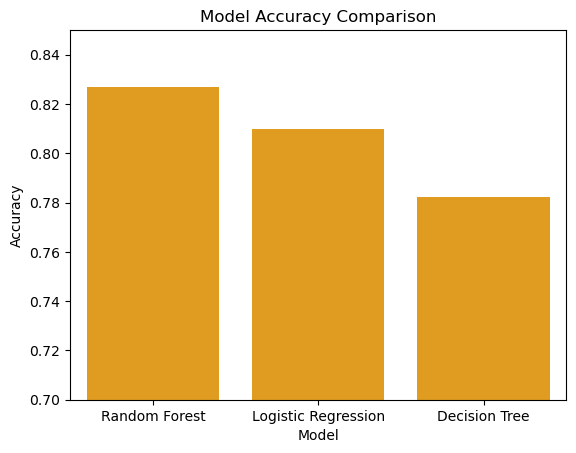

In [37]:
sns.barplot(x='Model', y='Accuracy', data=df_accuracy,color='orange')
plt.title("Model Accuracy Comparison")
plt.ylim(0.7, 0.85)
plt.show()